In [182]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import make_regression

In [183]:
df = pd.read_csv('Housing_cleaned.csv')
df

,Unnamed: 0,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefare,furnishingstatus
0,0,13300000,7420,4,2,3,1,2,2,2,1,2,1,1
1,1,12250000,8960,4,4,4,1,2,2,2,1,3,2,1
2,2,12250000,9960,3,2,2,1,2,1,2,2,2,1,2
3,3,12215000,7500,4,2,2,1,2,1,2,1,3,1,1
4,4,11410000,7420,4,1,2,1,1,1,2,1,2,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,540,1820000,3000,2,1,1,1,2,1,2,2,2,2,3
541,541,1767150,2400,3,1,1,2,2,2,2,2,0,2,2
542,542,1750000,3620,2,1,1,1,2,2,2,2,0,2,3
543,543,1750000,2910,3,1,1,2,2,2,2,2,0,2,1


In [184]:
df = df.drop('Unnamed: 0', axis=1)
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefare,furnishingstatus
0,13300000,7420,4,2,3,1,2,2,2,1,2,1,1
1,12250000,8960,4,4,4,1,2,2,2,1,3,2,1
2,12250000,9960,3,2,2,1,2,1,2,2,2,1,2
3,12215000,7500,4,2,2,1,2,1,2,1,3,1,1
4,11410000,7420,4,1,2,1,1,1,2,1,2,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,2,1,2,2,2,2,3
541,1767150,2400,3,1,1,2,2,2,2,2,0,2,2
542,1750000,3620,2,1,1,1,2,2,2,2,0,2,3
543,1750000,2910,3,1,1,2,2,2,2,2,0,2,1


In [185]:
new_order = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefare', 'furnishingstatus', 'price']

In [186]:
df1 = df[new_order]
df1

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefare,furnishingstatus,price
0,7420,4,2,3,1,2,2,2,1,2,1,1,13300000
1,8960,4,4,4,1,2,2,2,1,3,2,1,12250000
2,9960,3,2,2,1,2,1,2,2,2,1,2,12250000
3,7500,4,2,2,1,2,1,2,1,3,1,1,12215000
4,7420,4,1,2,1,1,1,2,1,2,2,1,11410000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,2,1,2,2,2,2,3,1820000
541,2400,3,1,1,2,2,2,2,2,0,2,2,1767150
542,3620,2,1,1,1,2,2,2,2,0,2,3,1750000
543,2910,3,1,1,2,2,2,2,2,0,2,1,1750000


In [187]:
X = df1.drop(columns =['price'])
y = df1['price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [188]:
# 3. Initialize the Random Forest regressor
# n_estimators: The number of trees in the forest (e.g., 100)
# random_state: Set for reproducibility
rf_regressor = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
# Evaluate using Mean Squared Error (MSE) or R-squared, not Accuracy.

In [189]:
# 4. Train the Model (Fit to the training data)
print("Training the Random Forest Regressor...")
rf_regressor.fit(X_train, y_train)
print("Training complete.")

Training the Random Forest Regressor...
Training complete.


In [190]:
y_pred = rf_regressor.predict(X_test)

In [191]:
rf_regressor.score(X_test, y_test)

0.5716660307293375

In [192]:
# Accessing Attributes: 
rf_regressor.feature_importances_

array([0.49405905, 0.04530094, 0.14004484, 0.0525584 , 0.00755064,
       0.01426888, 0.0364706 , 0.02181446, 0.04613369, 0.06609   ,
       0.02503614, 0.05067236])

In [193]:
# Calculate Mean Squared Error (MSE) - Lower is better
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")

Mean Squared Error (MSE): 1844573641063.73


In [194]:
# Calculate Root Mean Squared Error (RMSE) - Lower is better, more interpretable
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Root Mean Squared Error (RMSE): 1358150.82


In [195]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'R-squared (R²): {r2:.2f}')

Mean Squared Error (MSE): 1844573641063.73
R-squared (R²): 0.57


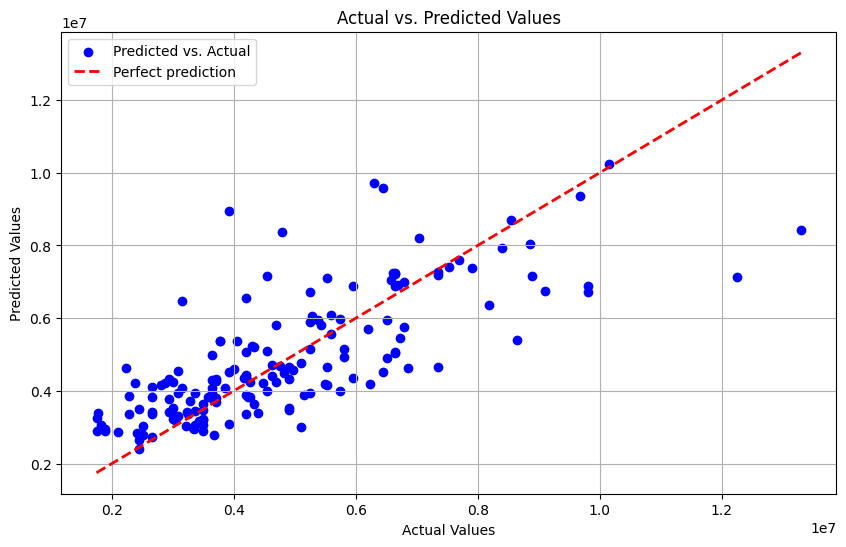

In [196]:
# Plot actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs. Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.title('Actual vs. Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

In [197]:
# Optional: Feature Importance
print("\nFeature Importance (Top 5):")
importances = rf_regressor.feature_importances_
feature_indices = np.argsort(importances)[::-1] # Get indices sorted by importance
for i in range(5):
    print(f"  Feature {feature_indices[i]}: {importances[feature_indices[i]]:.4f}")



Feature Importance (Top 5):
  Feature 0: 0.4941
  Feature 2: 0.1400
  Feature 9: 0.0661
  Feature 3: 0.0526
  Feature 11: 0.0507


In [198]:
# Interactive prediction function
def predict_price_interactive():
    print("Enter the following details to predict house price:")
    area = float(input("Area (in sqft): "))
    bedrooms = int(input("Number of bedrooms: "))
    bathrooms = int(input("Number of bathrooms: "))
    stories = int(input("Number of stories: "))
    mainroad = int(input("Main road? (1 = yes, 2 = no): "))
    guestroom = int(input("Guest room? (1 = yes, 2 = no): "))
    basement = int(input("Basement? (1 = yes, 2 = no): "))
    hotwaterheating = int(input("Hot water heating? (1 = yes, 2 = no): "))
    airconditioning = int(input("Air conditioning? (1 = yes, 2 = no): "))
    parking = int(input("Number of parking spaces: "))
    prefare = int(input("Preferred area? (1 = yes, 2 = no): "))
    furnishingstatus = int(input("Furnishing status? (0 = unfurnished, 1 = furnished, 2 = semi-furnished): "))

    input_data = pd.DataFrame([[
        area, bedrooms, bathrooms, stories, mainroad, guestroom, basement,
        hotwaterheating, airconditioning, parking, prefare, furnishingstatus
    ]], columns= X.columns)

    predicted_price = rf_regressor.predict(input_data)[0]
    print(f"\n🏠 Predicted House Price: ₹ {predicted_price:,.2f}")

# Call this to test
predict_price_interactive()


Enter the following details to predict house price:


Area (in sqft):  7420
Number of bedrooms:  4
Number of bathrooms:  2
Number of stories:  3
Main road? (1 = yes, 2 = no):  1
Guest room? (1 = yes, 2 = no):  2
Basement? (1 = yes, 2 = no):  2
Hot water heating? (1 = yes, 2 = no):  2
Air conditioning? (1 = yes, 2 = no):  1
Number of parking spaces:  2
Preferred area? (1 = yes, 2 = no):  1
Furnishing status? (0 = unfurnished, 1 = furnished, 2 = semi-furnished):  1



🏠 Predicted House Price: ₹ 8,413,258.70


Area (in sqft):  7420
Number of bedrooms:  4
Number of bathrooms:  2
Number of stories:  3
Main road? (1 = yes, 2 = no):  1
Guest room? (1 = yes, 2 = no):  2
Basement? (1 = yes, 2 = no):  2
Hot water heating? (1 = yes, 2 = no):  2
Air conditioning? (1 = yes, 2 = no):  1
Number of parking spaces:  2
Preferred area? (1 = yes, 2 = no):  1
Furnishing status? (0 = unfurnished, 1 = furnished, 2 = semi-furnished):  1



🏠 Predicted House Price: ₹ 8,004,072.41


In [199]:
df1['area'].unique()

array([ 7420,  8960,  9960,  7500,  8580, 16200,  8100,  5750, 13200,
        6000,  6550,  3500,  7800,  6600,  8500,  4600,  6420,  4320,
        7155,  8050,  4560,  8800,  6540,  8875,  7950,  5500,  7475,
        7000,  4880,  5960,  6840,  7482,  9000,  6360,  6480,  4300,
        7440,  6325,  5150, 11440,  7680,  8880,  6240, 11175,  7700,
       12090,  4000,  5020,  4040,  4260,  6500,  5700, 10500,  3760,
        8250,  6670,  3960,  7410,  5000,  6750,  4800,  7200,  4100,
        6400,  6350,  4500,  5450,  3240,  6615,  8372,  9620,  6800,
        8000,  6900,  3700,  7020,  7231,  6254,  7320,  6525, 15600,
        7160, 11460,  5828,  5200,  5400,  4640,  5800,  6660,  4700,
        5136,  4400,  3300,  3650,  6100,  2817,  7980,  3150,  6210,
        6825,  6710,  6450, 10269,  8400,  5300,  3800,  9800,  8520,
        6050,  7085,  3180,  3410,  3000, 11410,  5720,  3540,  7600,
       10700,  8150,  4410,  7686,  2800,  5948,  4200,  4520,  4095,
        4120,  4770,